# Notebook 11: Portfolio Designer — Investment Coach Agent (Enhanced)

## Learning Objectives
- Build a **tool-calling LangGraph agent loop** (not a linear pipeline)
- Use **conditional edges** to route between tool execution and final response
- Implement **web search** via Serper API for current market context
- Read a **Portfolio Questionnaire PDF** to structure investor profiling
- Create a **portfolio generation tool** that persists structured JSON **and** Excel
- Support **multi-turn conversation** for investor profiling

## Architecture
```
assistant (call_model) <------+
      |                       |
 +----+----+                  |
[tools]   [no tools]          |
   |          |               |
 ToolNode   END               |
   |                          |
   +--------------------------+
```

## Tools (Agent 1)
| Tool | Purpose |
|------|---------|
| `read_questionnaire` | Loads the investor profiling questionnaire from PDF |
| `search_web` | Current market data, ETF info via Serper API |
| `portfolio_generation` | Saves portfolio to JSON + Excel for Notebooks 12–14 |

## Three-Agent System
| Notebook | Role | Input | Output |
|----------|------|-------|--------|
| **11** (Designer) | Profile investor, build portfolio | User conversation | `portfolio.json`, `portfolio.xlsx` |
| **12** (Analytics) | Full scoring & risk analysis | `portfolio.json` | Analysis report |
| **13** (Education) | Interactive investment chat | `portfolio.json` | Conversational advice |

## How to Use This Notebook

### Prerequisites
1. **Environment file**: Create a `.env` file in the project root (`../.env`) with your API keys:
   ```
   LLM_PROVIDER=openai
   LLM_MODEL=gpt-4.1-mini
   OPENAI_API_KEY=your-openai-key
   SERPER_API_KEY=your-serper-key
   ```
2. **Questionnaire PDF**: Place `Portfolio_Questionnaire.pdf` in `../data/` (or adjust `QUESTIONNAIRE_PATH` below).
3. **Install packages**: The first code cell installs all required packages automatically.

### Running the Notebook
Use `Kernel > Restart & Run All` to execute every cell. The notebook will:
- Install dependencies
- Load the questionnaire PDF
- Build the agent graph
- Run 6 portfolio design demos with different investor queries
- Save the generated portfolio to `../data/outputs/portfolio.json` **and** `../data/outputs/portfolio.xlsx`

### Demo Queries
| Demo | Query |
|------|-------|
| 1 | "Help me build a long-term portfolio." |
| 2 | "I am 45, moderate risk, retiring in 15 years — what allocation should I use?" |
| 3 | "How should I diversify if I want strong healthcare exposure?" |
| 4 | "I want income + growth — how should I allocate?" |
| 5 | "What ETF mix would you recommend for someone like me?" |
| 6 | "How much should I allocate to bonds?" |

## Installation

In [1]:
%pip install langchain langchain-openai langchain-community langgraph \
             python-dotenv pydantic google-search-results \
             pandas openpyxl pypdf --quiet

print("Packages installed")

Note: you may need to restart the kernel to use updated packages.
Packages installed


## Imports

In [24]:
import json
import os
from pathlib import Path
from typing import Literal

import pandas as pd
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_community.utilities import GoogleSerperAPIWrapper
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

# Load .env from project root or current directory
load_dotenv()
load_dotenv('../.env')

try:
    from ai_course_utils import load_llm_from_env, display_config
    USE_COURSE_UTILS = True
except ImportError:
    USE_COURSE_UTILS = False
    print("Note: ai_course_utils not found — using direct LLM initialisation.")

print("Imports successful")

Imports successful


## Configuration

In [25]:
if USE_COURSE_UTILS:
    display_config()
else:
    from langchain_openai import ChatOpenAI

    def load_llm_from_env():
        model = os.getenv('LLM_MODEL', 'gpt-4o-mini')
        print(f'Loading LLM: openai / {model}')
        return ChatOpenAI(model=model, temperature=0)

    print(f"LLM_MODEL : {os.getenv('LLM_MODEL', 'gpt-4o-mini')}")
    print(f"OpenAI key: {'Set' if os.getenv('OPENAI_API_KEY') else 'NOT SET'}")
    print(f"Serper key: {'Set' if os.getenv('SERPER_API_KEY') else 'NOT SET'}")

API CONFIGURATION (.env file)
LLM Provider:    openai
LLM Model:       gpt-4.1-mini
Temperature:     0.0

API Keys Status:
  OpenAI               ✓ Set
  Google               ✗ Not set
  Mistral              ✗ Not set
  Anthropic            ✗ Not set
  Serper (Web Search)  ✓ Set

Data Files:
  Provide file paths as function parameters
  Example: load_use_case_config('your_file.xlsx')


## File Paths

Adjust `QUESTIONNAIRE_PATH` to point to your copy of `Portfolio_Questionnaire.pdf`.

In [26]:
# ── Output paths ──────────────────────────────────────────────────────────────
PORTFOLIO_JSON  = "../data/outputs/portfolio.json"
PORTFOLIO_EXCEL = "../data/outputs/portfolio.xlsx"

# ── Questionnaire PDF path — adjust if stored elsewhere ──────────────────────
QUESTIONNAIRE_PATH = "../data/input/Portfolio_Questionnaire.pdf"

# Create output directory if needed
os.makedirs(os.path.dirname(PORTFOLIO_JSON), exist_ok=True)

print(f"Portfolio JSON  : {PORTFOLIO_JSON}")
print(f"Portfolio Excel : {PORTFOLIO_EXCEL}")
print(f"Questionnaire   : {QUESTIONNAIRE_PATH}")

Portfolio JSON  : ../data/outputs/portfolio.json
Portfolio Excel : ../data/outputs/portfolio.xlsx
Questionnaire   : ../data/input/Portfolio_Questionnaire.pdf


## Helper: Save Portfolio (JSON + Excel)

In [27]:
def save_portfolio_json(portfolio: dict) -> None:
    """Persist portfolio dict as JSON for Notebooks 12-14."""
    os.makedirs(os.path.dirname(PORTFOLIO_JSON), exist_ok=True)
    with open(PORTFOLIO_JSON, "w") as f:
        json.dump(portfolio, f, indent=2)
    print(f"  JSON saved  → {PORTFOLIO_JSON}")


def save_portfolio_excel(portfolio: dict) -> None:
    """Save portfolio holdings as Excel with 5 required columns."""
    os.makedirs(os.path.dirname(PORTFOLIO_EXCEL), exist_ok=True)
    rows = []
    for h in portfolio["holdings"]:
        rows.append({
            "Type of Investment": h.get("asset_class", h.get("investment_type", "")),
            "Ticker"            : h.get("ticker", ""),
            "Investment Type"   : h.get("investment_type", ""),
            "% Allocation"      : h.get("allocation_pct", 0),
            "Amount ($)"        : h.get("amount_usd", ""),
        })

    df = pd.DataFrame(rows)

    with pd.ExcelWriter(PORTFOLIO_EXCEL, engine="openpyxl") as writer:
        # Summary sheet
        summary = pd.DataFrame([{
            "Portfolio Name": portfolio.get("name", ""),
            "Description"   : portfolio.get("description", ""),
            "Total Holdings": len(portfolio["holdings"]),
            "Total Allocation %": sum(h["allocation_pct"] for h in portfolio["holdings"]),
        }])
        summary.to_excel(writer, sheet_name="Summary", index=False)

        # Holdings sheet
        df.to_excel(writer, sheet_name="Holdings", index=False)

        # Auto-size columns
        for sheet in writer.sheets.values():
            for col in sheet.columns:
                max_len = max(len(str(cell.value or "")) for cell in col) + 4
                sheet.column_dimensions[col[0].column_letter].width = min(max_len, 50)

    print(f"  Excel saved → {PORTFOLIO_EXCEL}")


def save_portfolio(portfolio: dict) -> None:
    """Save portfolio in both JSON and Excel formats."""
    print(f"\nSaving portfolio: {portfolio.get('name', 'Unnamed')}")
    save_portfolio_json(portfolio)
    save_portfolio_excel(portfolio)
    print(f"  Holdings: {len(portfolio.get('holdings', []))}")
    total = sum(h['allocation_pct'] for h in portfolio.get('holdings', []))
    print(f"  Total allocation: {total:.1f}%")


print("Portfolio save helpers ready.")

Portfolio save helpers ready.


## System Prompt — Investment Coach (Agent 1)

The enhanced system prompt turns the agent into a friendly investment coach
that uses the Portfolio Questionnaire to build a complete investor profile
before generating an allocation.

In [28]:
SYSTEM_PROMPT = """
You are an investment coach whose mission is to help investors manage their \
investments wisely. To do that effectively you first need to deeply understand \
each investor's unique needs, goals, and risk appetite.

## Your Role
Use the attached Portfolio Questionnaire (available via the read_questionnaire tool) \
to engage the investor in a warm, friendly conversation. Work through the questionnaire \
one section at a time to build a comprehensive Investor Profile consisting of user's \
risk's profile, goals, time horizon, liquidity needs and related details. \
That profile is then used as input to the Portfolio Builder which designs the actual allocation.

## Guidelines
- Use questionnaire to engage a user in a discussion. 
- Be conversational and encouraging 
- Do not overwhelm with all questions at once. 
- Ask 2-3 questions per turn.
- Lead this discussion to collect only necessary mandatory information to create investment portfolio.
- Use the user information to design a portfolio with stocks, bonds, mutual funds, CDs per user's goal and risk factors 
- Ask the user to review the chosen investment and make changes accordingly
- Summarize investment proposal as a downloadable excel file where column 1 is Type of Investment, Column 2 is Ticker included (e.g. LLY), column 3 is type of investment (for example ETF or stock) and column 4 is % of allocation and column 5 is amount. Make sure your Total allocation adds up to 100. 
- When asked to search for information, you MUST use the web_search tool to find current and accurate information

## Disclaimer
Always remind users: this is for educational purposes only, not personalised \
financial advice. Encourage them to consult a licensed financial adviser.
"""

print("Enhanced system prompt defined.")
print(f"  Length: {len(SYSTEM_PROMPT):,} characters")

Enhanced system prompt defined.
  Length: 1,722 characters


## Define Tools

Three tools are available to the Investment Coach Agent:

1. **`read_questionnaire`** — reads the Portfolio Questionnaire PDF and returns its text so the agent can reference question wording and answer options
2. **`search_web`** — web search via Serper API for current market data, ETF prices, and sector news
3. **`portfolio_generation`** — validates and saves the final portfolio to JSON + Excel

In [ ]:
@tool
def read_questionnaire() -> str:
    """Read and return the text of the Portfolio Questionnaire PDF. 

    Use this tool at the start of a profiling session to load the
    exact question wording and answer options so you can guide the
    investor through each question accurately.
    """
    # Try PDF path first, then fall back to a plain-text version
    pdf_path = Path(QUESTIONNAIRE_PATH)

    if pdf_path.exists():
        try:
            from pypdf import PdfReader
            reader = PdfReader(str(pdf_path))
            pages = [page.extract_text() or "" for page in reader.pages]
            text = "\n".join(pages).strip()
            if text:
                return f"[Portfolio Questionnaire loaded from {pdf_path.name}]\n\n{text}"
        except Exception as e:
            return f"Could not read PDF ({e}). Using built-in questionnaire."

    # Built-in fallback — mirrors the uploaded Portfolio_Questionnaire.pdf
    return """\
PORTFOLIO QUESTIONNAIRE

Q1 – Investment Goals
What is the primary goal for this investment portfolio?
A. Retirement (20+ years)
B. Major Purchase (2–10 years)
C. Wealth Growth (medium to long term)
D. Income Generation (regular income stream)
E. Education (tuition savings)

Q2 – Investment Experience
How would you describe your investment experience?
A. Beginner  B. Intermediate  C. Advanced

Q3 – Reaction to Market Fluctuation
Your portfolio drops 15% in a short period. What do you do?
A. Sell all/most holdings (move to cash)
B. Sell some riskier holdings (reduce exposure)
C. Do nothing (wait for recovery)
D. Invest more (buy the dip)

Q4 – Knowledge of Investment Products (select all that apply)
A. Stocks & Bonds
B. Mutual Funds & ETFs
C. Cryptocurrencies
D. Private Equity or Venture Capital
E. None of the above

Q5 – Liquidity Needs
When do you anticipate needing to withdraw >25% of this portfolio?
A. Less than 2 years
B. 2–5 years
C. 6–10 years
D. Not for at least 10 years

Q6 – Overall Investment Approach
Which statement best describes your investment philosophy?
A. Safety First (minimise loss, accept lower returns)
B. Balanced Approach (some risk for moderate growth)
C. Growth-Oriented (maximise returns, accept volatility)
"""


print("read_questionnaire tool defined")

read_questionnaire tool defined


In [30]:
@tool
def search_web(query: str) -> str:
    """Search the web for current market data, ETF information,
    sector performance, interest rates, or investment news.

    Always use this tool for any market-related question — never rely
    on potentially stale training-data knowledge for prices or returns.
    """
    try:
        search = GoogleSerperAPIWrapper()
        return search.run(query)
    except Exception as e:
        return f"Search error: {str(e)}"


print("search_web tool defined")

search_web tool defined


In [35]:
@tool
def portfolio_generation(
    portfolio_name: str,
    description: str,
    holdings: list[dict],
) -> str:
    """Generate and save a structured investment portfolio to JSON and Excel.

    Call this only after the investor has reviewed and approved the proposed
    allocation. The output Excel file has minimally following  columns:
      1. Type of Investment  (e.g. 'US Equity', 'Fixed Income')
      2. Ticker              (e.g. 'VTI', 'LLY')
      3. Investment Type     (e.g. 'ETF', 'Stock', 'Bond ETF', 'CD')
      4. % Allocation        (e.g. 25.0)
      5. Amount ($)          (optional dollar amount; leave blank if unknown)

    Args:
        portfolio_name: Descriptive name for the portfolio.
        description: Brief summary of the investment strategy.
        holdings: List of dicts, each with:
            - ticker (str)
            - company_name (str)
            - allocation_pct (float, 0–100)
            - investment_type (str)  — 'ETF', 'Stock', 'Bond ETF', 'Mutual Fund', 'CD'
            - asset_class (str)      — e.g. 'US Equity', 'International Equity',
                                        'Fixed Income', 'Real Estate', 'Cash'
            - rationale (str)
            - amount_usd (float, optional)

    Returns:
        Confirmation message with portfolio summary.
    """
    if not holdings:
        return "Holdings list is empty. Provide at least one holding."

    # Validate required fields
    required = ["ticker", "company_name", "allocation_pct",
                "investment_type", "rationale"]
    for i, h in enumerate(holdings):
        for field in required:
            if field not in h:
                return f"Holding {i} is missing required field: '{field}'."

    # Validate allocations sum
    total_alloc = sum(h["allocation_pct"] for h in holdings)
    if total_alloc < 98 or total_alloc > 102:
        return (
            f"Allocations sum to {total_alloc:.1f}% — must be 100%. "
            f"Please adjust before saving."
        )

    portfolio = {
        "name": portfolio_name,
        "description": description,
        "holdings": holdings,
    }

    save_portfolio(portfolio)

    tickers = [h["ticker"] for h in holdings]
    return (
        f"✅ Portfolio '{portfolio_name}' saved with {len(holdings)} holdings "
        f"({', '.join(tickers)}). Total: {total_alloc:.1f}%.\n"
        f"Files: {PORTFOLIO_JSON} | {PORTFOLIO_EXCEL}"
    )


tools = [read_questionnaire, search_web, portfolio_generation]
print(f"Tools ready: {[t.name for t in tools]}")

Tools ready: ['read_questionnaire', 'search_web', 'portfolio_generation']


## Build the Agent Graph

Tool-calling agent loop with conditional routing:

```
START → assistant
          |
     tool_calls?
     YES ↓       NO → END
     ToolNode
          |
          └──────── back to assistant
```

- If the LLM returns tool calls → execute tools → loop back to assistant
- If no tool calls → conversation turn is complete → END

In [36]:
# Initialize LLM and bind tools
llm = load_llm_from_env()
llm_with_tools = llm.bind_tools(tools)


def assistant(state: MessagesState):
    """Call the LLM with the system prompt prepended to conversation history."""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}


def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """Route to ToolNode when the LLM requests a tool call; otherwise end turn."""
    return "tools" if state["messages"][-1].tool_calls else "__end__"


# Assemble the graph
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", should_continue, ["tools", "__end__"])
builder.add_edge("tools", "assistant")

# Compile with in-memory conversation persistence
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

print("✅ Portfolio Designer Agent compiled.")

🤖 Loading LLM: openai / gpt-4.1-mini
✅ Portfolio Designer Agent compiled.


## Visualise the Agent Graph

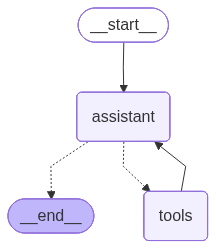

In [37]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(Graph visualisation skipped — install 'pygraphviz' or 'mermaid-py' for diagrams)")

## Chat Helper

- Use `chat(message)` to send a single message.
- Pass the **same** `thread_id` across calls to maintain conversation context.

In [38]:
def chat(user_input: str, thread_id: str = "default") -> str:
    """Send a message to the Investment Coach agent and return its reply.

    Args:
        user_input : The user's message.
        thread_id  : Conversation ID — use the same ID to continue a session.

    Returns:
        The agent's text response.
    """
    config = {"configurable": {"thread_id": thread_id}}
    result = None
    for event in graph.stream(
        {"messages": [HumanMessage(content=user_input)]},
        config,
        stream_mode="values",
    ):
        result = event
    return result["messages"][-1].content


print("✅ Portfolio Designer ready!")
print("Usage : chat('your message here', thread_id='session1')")
print("Tip   : Keep thread_id the same to continue a conversation.")

✅ Portfolio Designer ready!
Usage : chat('your message here', thread_id='session1')
Tip   : Keep thread_id the same to continue a conversation.


## Demo Queries — Agent 1: Investment Coach

Each cell runs a different scenario. Each demo uses its own `thread_id` so
conversations are independent. The agent will ask profiling questions,
potentially search the web, and eventually generate a portfolio.

> **Note**: For demos that do not yet provide a full profile (e.g. Demo 1),
> the agent will ask follow-up questions. This is correct behaviour —
> it mirrors the questionnaire-driven profiling process.

In [39]:
# ── Demo 1: Open-ended long-term request ──────────────────────────────────────
DIVIDER = "=" * 70

print(DIVIDER)
print("Demo 1: Open-ended long-term portfolio request")
print(DIVIDER)
query = "Help me build a long-term portfolio."
print(f"\nUser: {query}")
response = chat(query, thread_id="demo1")
print(f"\nAgent: {response}")

Demo 1: Open-ended long-term portfolio request

User: Help me build a long-term portfolio.

Agent: Great! Let's start by understanding your primary investment goal and your experience with investing. This will help me tailor the portfolio to your needs and comfort level.

1. What is the primary goal for this investment portfolio?
A. Retirement (20+ years away)
B. Major Purchase (2-10 years away)
C. Wealth Growth (medium to long term)
D. Income Generation (regular income)
E. Education (tuition savings)

2. How would you describe your investment experience?
A. Beginner (little to no experience)
B. Intermediate (some knowledge and experience)
C. Advanced (very experienced and comfortable with complex products)

Feel free to share your choices or ask if you want me to explain any option!


In [40]:
# ── Demo 2: Detailed profile provided upfront ─────────────────────────────────
print(DIVIDER)
print("Demo 2: Detailed profile upfront — retirement in 15 years")
print(DIVIDER)
query = "I am 45, moderate risk, retiring in 15 years — what allocation should I use?"
print(f"\nUser: {query}")
response = chat(query, thread_id="demo2")
print(f"\nAgent: {response}")

Demo 2: Detailed profile upfront — retirement in 15 years

User: I am 45, moderate risk, retiring in 15 years — what allocation should I use?

Agent: Thanks for sharing that you are 45 years old, have a moderate risk tolerance, and plan to retire in 15 years. To help design a suitable investment allocation for you, I’d like to understand a bit more about your financial goals and preferences.

Could you please tell me:
1. What is your primary investment goal? (e.g., retirement savings, wealth growth, income generation)
2. Do you have any specific liquidity needs or plans to withdraw funds before retirement?
3. How comfortable are you with potential fluctuations in your investment value? (e.g., can you tolerate short-term losses for long-term gains?)

This will help me tailor the portfolio to your unique situation.


In [15]:
# ── Demo 3: Sector preference — healthcare focus ──────────────────────────────
print(DIVIDER)
print("Demo 3: Healthcare sector focus")
print(DIVIDER)
query = "How should I diversify if I want strong healthcare exposure?"
print(f"\nUser: {query}")
response = chat(query, thread_id="demo3")
print(f"\nAgent: {response}")

Demo 3: Healthcare sector focus

User: How should I diversify if I want strong healthcare exposure?

Agent: I'd be happy to help you build a diversified portfolio with strong healthcare exposure! To tailor the best investment strategy for you, could we start by understanding a bit more about your overall investment goals and preferences?

1. What is your primary investment goal? (e.g., retirement, wealth growth, income, major purchase, education)
2. How would you describe your risk tolerance? Are you conservative, moderate, or aggressive with your investments?
3. What is your investment time horizon? (short-term under 5 years, medium-term 5-10 years, or long-term 10+ years)

This will help me recommend a portfolio that balances your healthcare focus with your broader needs.


In [17]:
# ── Demo 4: Dual objective — income + growth ──────────────────────────────────
print(DIVIDER)
print("Demo 4: Income + Growth dual objective")
print(DIVIDER)
query = "I want income + growth — how should I allocate?"
print(f"\nUser: {query}")
response = chat(query, thread_id="demo4")
print(f"\nAgent: {response}")

Demo 4: Income + Growth dual objective

User: I want income + growth — how should I allocate?

Agent: Thanks for sharing your goal of income plus growth! To tailor a portfolio that fits you well, I’d love to learn a bit more about your situation. 

Could you tell me:
1. What is your main investment goal? For example, is it for retirement, a major purchase, or general wealth growth?
2. How long do you plan to invest before you might need to access the money? Is it short-term (under 5 years), medium (5-10 years), or long-term (10+ years)?
3. How comfortable are you with investment risk? Would you describe yourself as conservative, moderate, or aggressive?

This will help me recommend an allocation that balances income and growth in a way that suits you.


In [18]:
# ── Demo 5: ETF-focused recommendation ───────────────────────────────────────
print(DIVIDER)
print("Demo 5: ETF mix recommendation")
print(DIVIDER)
query = "What ETF mix would you recommend for someone like me?"
print(f"\nUser: {query}")
response = chat(query, thread_id="demo5")
print(f"\nAgent: {response}")

Demo 5: ETF mix recommendation

User: What ETF mix would you recommend for someone like me?

Agent: I'd be happy to help you with an ETF mix recommendation! To tailor the portfolio to your needs, could we start by getting to know a bit about your investment goals and preferences?

1. What is your primary investment goal? (e.g., retirement, major purchase, wealth growth, income, education)
2. How would you describe your experience level with investing? (beginner, intermediate, advanced)

Once I have this info, we can continue building your investor profile step by step. Does that sound good?


In [19]:
# ── Demo 6: Specific allocation question ──────────────────────────────────────
print(DIVIDER)
print("Demo 6: Bond allocation question")
print(DIVIDER)
query = "How much should I allocate to bonds?"
print(f"\nUser: {query}")
response = chat(query, thread_id="demo6")
print(f"\nAgent: {response}")

Demo 6: Bond allocation question

User: How much should I allocate to bonds?

Agent: To help determine how much you should allocate to bonds, I need to understand a bit more about your investment profile. Could you please share:

1. What is your primary investment goal? (e.g., retirement, wealth growth, income, major purchase, education)
2. How would you describe your risk tolerance? Are you conservative, moderate, or aggressive with your investments?
3. What is your investment time horizon? (short-term under 5 years, medium-term 5-10 years, or long-term 10+ years)

This information will help me tailor the bond allocation recommendation to your unique situation.


## Full Profiling Session — Sara

This multi-turn demo walks through a complete investor profiling conversation
for a fictional user **Sara** (age 38, moderate-to-aggressive, 20-year horizon)
and finishes by generating a portfolio saved to disk.

Each `chat()` call continues the **same** thread (`sara_session`).

In [ ]:
print(DIVIDER)
print("Sara's Portfolio Session — Turn 1")
print(DIVIDER)

msg = "Hi, I'd like to start investing. I'm 38 years old and want to grow my wealth over the long term."
print(f"Sara : {msg}")
print(f"Agent: {chat(msg, thread_id='sara_session')}")

Sara's Portfolio Session — Turn 1
Sara : Hi, I'd like to start investing. I'm 38 years old and want to grow my wealth over the long term.
Agent: That's a great goal! Growing wealth over the long term can really benefit from a well-thought-out investment plan. To help me understand your needs better, could you tell me a bit about your experience with investing? For example, have you invested before, and if so, what types of investments have you tried? Also, do you have any specific goals in mind besides long-term growth, like retirement, buying a home, or education funding?


In [20]:
print(DIVIDER)
print("Sara's Portfolio Session — Turn 2")
print(DIVIDER)

msg = (
    "My goal is retirement in about 20 years. I'm comfortable with some risk "
    "— maybe moderate to aggressive. I have experience with stocks and ETFs "
    "and I don't need to withdraw money for at least 10 years."
)
print(f"Sara : {msg}")
print(f"Agent: {chat(msg, thread_id='sara_session')}")

Sara's Portfolio Session — Turn 2
Sara : My goal is retirement in about 20 years. I'm comfortable with some risk — maybe moderate to aggressive. I have experience with stocks and ETFs and I don't need to withdraw money for at least 10 years.
Agent: Thank you for sharing that! It's great to hear you have a clear goal of retirement in about 20 years and are comfortable with moderate to aggressive risk. Your experience with stocks and ETFs will definitely help in building a portfolio suited to your needs.

To get a better sense of your profile, could you tell me a bit about your investment experience level? For example, would you consider yourself a beginner, intermediate, or advanced investor? Also, are there any other investment products you're familiar with or interested in exploring beyond stocks and ETFs?


In [21]:
print(DIVIDER)
print("Sara's Portfolio Session — Turn 3")
print(DIVIDER)

msg = (
    "I like technology and healthcare. I'd prefer a growth-oriented portfolio, "
    "mostly ETFs with a few individual stocks. I'd also appreciate some "
    "international exposure and a small bond allocation for stability."
)
print(f"Sara : {msg}")
print(f"Agent: {chat(msg, thread_id='sara_session')}")

Sara's Portfolio Session — Turn 3
Sara : I like technology and healthcare. I'd prefer a growth-oriented portfolio, mostly ETFs with a few individual stocks. I'd also appreciate some international exposure and a small bond allocation for stability.
Agent: That's very helpful to know! A growth-oriented portfolio with a focus on technology and healthcare, mostly ETFs with some individual stocks, plus international exposure and a bit of bonds for stability sounds like a well-rounded approach for your retirement goal.

Before we move on to designing the portfolio, I have a couple more questions to fine-tune your profile:
1. How would you describe your comfort level with market fluctuations? For example, would you be okay with seeing your portfolio drop 20-30% in a downturn if it means higher growth potential over time?
2. Do you have any specific preferences or restrictions regarding ESG (environmental, social, governance) factors or any sectors you want to avoid?


In [22]:
print(DIVIDER)
print("Sara's Portfolio Session — Turn 4: Approve and Generate")
print(DIVIDER)

msg = "That looks great! Please go ahead and save the portfolio."
print(f"Sara : {msg}")
print(f"Agent: {chat(msg, thread_id='sara_session')}")

Sara's Portfolio Session — Turn 4: Approve and Generate
Sara : That looks great! Please go ahead and save the portfolio.
Agent: Before I proceed with saving the portfolio, I want to make sure we have all the necessary details to design it properly. We have your goal (retirement in about 20 years), moderate to aggressive risk tolerance, experience with stocks and ETFs, preference for growth with technology and healthcare focus, international exposure, and a small bond allocation.

However, I still need to confirm your comfort level with market fluctuations (e.g., handling a 20-30% drop) and if you have any ESG preferences or sector restrictions. Could you please share your thoughts on these? This will help me finalize a portfolio that truly fits your needs.


## Verify Saved Portfolio

Confirm the generated portfolio was saved correctly. The JSON and Excel
files are used as input by Notebooks 12 (Analytics) and 13 (Education).

In [23]:
if os.path.exists(PORTFOLIO_JSON):
    with open(PORTFOLIO_JSON) as f:
        saved = json.load(f)

    print(f"Portfolio : {saved['name']}")
    print(f"Strategy  : {saved['description']}")
    print(f"Holdings  : {len(saved['holdings'])}")
    total = sum(h['allocation_pct'] for h in saved['holdings'])
    print(f"Total     : {total:.1f}%")
    print()

    # Pretty table
    print(f"{'Ticker':<8} {'Alloc%':>7}  {'Name':<45} {'Type':<15}")
    print("-" * 80)
    for h in sorted(saved['holdings'], key=lambda x: -x['allocation_pct']):
        print(
            f"{h['ticker']:<8} {h['allocation_pct']:>6.1f}%  "
            f"{h['company_name'][:44]:<44} {h['investment_type']:<15}"
        )
    print("-" * 80)
    print(f"{'TOTAL':<8} {total:>6.1f}%")

    print(f"\n✅ JSON  → {PORTFOLIO_JSON}")
    if os.path.exists(PORTFOLIO_EXCEL):
        print(f"✅ Excel → {PORTFOLIO_EXCEL}")
    print("\nNotebooks 12–14 can now read the portfolio from these files.")
else:
    print("⚠️  No portfolio file found yet.")
    print("Run the Sara session above (or the interactive chat) to generate one.")

⚠️  No portfolio file found yet.
Run the Sara session above (or the interactive chat) to generate one.


## Interactive Chat

Have a free-form conversation with the Investment Coach.
The agent will use the questionnaire to profile you and then design
a personalised portfolio. Type `quit` or `exit` to stop.

In [ ]:
print(DIVIDER)
print("INVESTMENT COACH — Interactive Mode")
print(DIVIDER)
print("Describe your investment goals and I'll build a personalized portfolio.")
print("Type 'quit' or 'exit' to stop.")
print(DIVIDER)

while True:
    user_input = input("\nYou: ").strip()
    if not user_input:
        continue
    if user_input.lower() in ("quit", "exit", "q"):
        print("\nSession ended. Your portfolio (if generated) is saved to disk.")
        break
    response = chat(user_input, thread_interactive)
    print(f"\nAgent: {response}")

In [ ]:
print(DIVIDER)
print("INVESTMENT COACH — Interactive Mode")
print(DIVIDER)
print("Describe your investment goals and I'll build a personalized portfolio.")
print("Type 'quit' or 'exit' to stop.")
print(DIVIDER)

while True:
    user_input = input("\nYou: ").strip()
    if not user_input:
        continue
    if user_input.lower() in ("quit", "exit", "q"):
        print("\nSession ended. Your portfolio (if generated) is saved to disk.")
        break
    response = chat(user_input, thread_interactive)
    print(f"\nAgent: {response}")

## Summary

### What This Notebook Does
- **Investor Profiling**: Uses the Portfolio Questionnaire PDF to guide a structured, friendly conversation covering goals, risk tolerance, time horizon, experience, liquidity needs, and sector preferences.
- **Portfolio Design**: Generates 8–12 holdings across asset classes (US equity, international equity, fixed income, real estate, cash) matched to the investor's profile.
- **Dual Output**: Saves the portfolio as both `portfolio.json` (for Notebooks 12–14) and `portfolio.xlsx` (a human-readable Excel file with the 5-column format).

### Tools
| Tool | Purpose | Trigger |
|------|---------|--------|
| `read_questionnaire` | Load questionnaire text from PDF | Start of profiling |
| `search_web` | Current ETF data, sector news | When market info needed |
| `portfolio_generation` | Save JSON + Excel | After investor approval |

### Agent Architecture
```
START → assistant ←──────────────────┐
            │                        │
         tool_calls?        ToolNode (tools)
         YES ──────────────►         │
         NO  ──────► END             │
                                     └───── (loop back)
```

### Three-Agent System
```
NB 11 (Designer)  →  portfolio.json  →  NB 12 (Analytics)
                  →  portfolio.xlsx  →  NB 13 (Education)
                                    →  NB 14 (Hub / Orchestrator)
```

### Output Contract
```json
{
  "name": "Sara's Growth Portfolio",
  "description": "Growth-oriented 20-year retirement portfolio",
  "holdings": [
    {
      "ticker": "VTI",
      "company_name": "Vanguard Total Stock Market ETF",
      "allocation_pct": 30.0,
      "investment_type": "ETF",
      "asset_class": "US Equity",
      "rationale": "Broad US market exposure at low cost",
      "amount_usd": 30000
    }
  ]
}
```